# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import correlate
from hapi import *
from pylab import plot
# from bin_spec import bin_spectrum

os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case/')
from bin_spec import bin_spectrum

%matplotlib widget

HAPI version: 1.3.0.0
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

# Configuration

In [2]:
DATA_DIR = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data"
hapi_data_dir = "HAPI_DB"
atmospheric_profile_path = "/Users/zaniaccollins/Research/SGL/sgl_science_case/data/external/atmosphere_profile.csv"

db_begin('/Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB')

Using /Users/zaniaccollins/Research/SGL/sgl_science_case/notebooks/HAPI_DB

CH4
                     Lines parsed: 2946
CH4_iso2
                     Lines parsed: 11300
H2O_iso3
                     Lines parsed: 763
N2_iso1
                     Lines parsed: 24
H2O_iso1
                     Lines parsed: 528
CH4_iso1
                     Lines parsed: 4093
H2O_main
                     Lines parsed: 1123
CH4_iso3
                     Lines parsed: 962
N2O_iso1
                     Lines parsed: 5027
H2O
                     Lines parsed: 15602
H2O_iso2
                     Lines parsed: 983


# User parameters

In [3]:
wl_min = 7.8
wl_max = 8.2
native_dwn = 0.001     # cm^-1, native HITRAN-resolution sampling (HAPI side)

wn_min = 1e4/wl_max
wn_max = 1e4/wl_min


In [4]:
df_atmospheric_profile_table = pd.read_csv(atmospheric_profile_path)

In [5]:
tableList()

dict_keys(['sampletab', 'CH4', 'CH4_iso2', 'H2O_iso3', 'N2_iso1', 'H2O_iso1', 'CH4_iso1', 'H2O_main', 'CH4_iso3', 'N2O_iso1', 'H2O', 'H2O_iso2'])

# Helper Functions

In [34]:
kB = 1.380649e-23  # Boltzmann constant, J/K

def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def compute_absorption_coefficient(molecule, isotope, dwn, altitude):
    """Compute absorption coefficient (cm^-1) for pure gas at layer conditions."""
    print(f"Computing coef for {molecule} iso{isotope} at alt {altitude}")
    M, __ = get_molecule_id(molecule)
    
    table_name = f"{molecule}_iso{isotope}"
    
    p_atm = df_atmospheric_profile_table["PRES_mb"].iloc[altitude] / 1013.25
    vmr = df_atmospheric_profile_table[f"{molecule}_ppmv"].iloc[altitude] / 1e6

    wn_grid, coef = absorptionCoefficient_Voigt(
        Components=[(M, isotope, vmr)],  # pure gas -> scale by vmr later
        Diluent={'self': vmr, 'air': 1.0 - vmr},
        SourceTables=table_name,
        WavenumberRange=(wn_min, wn_max),
        WavenumberStep=dwn,
        Environment={
            'T': df_atmospheric_profile_table["TEMP_K"].iloc[altitude], 
            'p': p_atm # Convert from mb to atmospheres
        },
        HITRAN_units=False  # Get absorption coefficient in cm^-1
    )

    
    
    return wn_grid, coef

def compute_reflectivity(molecules_isotopes, dwn, cloud_top = 8.0, albedo = 0.3): #cloud_top is in km
    '''
    Input: tuple list?: [(molecule, isotopes), ...], dwn, cloud_top (km), albedo

    computes intensity across wavelength for earth-like atmosphere

    Output: wavelengths_µm (array), transmission (array), wn_grid_ref (array)
    '''


    alt_df = df_atmospheric_profile_table.copy().reset_index(drop=True)
    
    # Layers above the cloud deck
    above_cloud_mask = alt_df["ALT_km"] >= cloud_top
    above_df = alt_df[above_cloud_mask].reset_index(drop=True)
    
    print(f"Computing reflectivity above cloud top at {cloud_top} km ({len(above_df)} layers)")
    
    alt_km = above_df["ALT_km"].values
    dz_km = np.diff(alt_km, append=alt_km[-1] + np.median(np.diff(alt_km)))
    dz_cm = dz_km * 1e5
    
    #temporary debug:
    # dz_cm *= 0.1

    total_tau = None
    wn_grid_ref = None
    
    for mol, iso in molecules_isotopes:
        col_name = f"{mol}_ppmv"   # <--- exact match to CSV
        print(f"Looking for column: {col_name}")
        if col_name not in alt_df.columns:
            print("ERROR: Column not found! Using available VMR-like columns:", [c for c in alt_df.columns if 'ppm' in c.lower() or 'vmr' in c.lower()])
            continue
            
        print(f"→ Processing {mol} iso{iso}")
        for i, row in above_df.iterrows():
            wn_grid, coef_pure = compute_absorption_coefficient(mol, iso, dwn, i)
            if wn_grid_ref is None:
                wn_grid_ref = wn_grid.copy()
            
            ppmv = float(row[col_name])
            vmr = ppmv * 1e-6
            
            delta_tau = coef_pure * vmr * dz_cm[i]
            
            if total_tau is None:
                total_tau = np.zeros_like(coef_pure)
            total_tau += delta_tau
            
            # if i % 15 == 0:
            #     print(f"  Layer {alt_km[i]:5.1f} km | ppmv={ppmv:8.2f} | vmr={vmr:.2e} | max_delta_tau={np.max(delta_tau):.2e} | cum_max_tau={np.max(total_tau):.2e}")
    
    if total_tau is None:
        raise ValueError("No tau accumulated")
    
    total_tau_roundtrip = 2*total_tau
    
    print(f"\nFINAL: max_tau_roundtrip = {np.max(total_tau_roundtrip):.2f}, mean_tau = {np.mean(total_tau_roundtrip):.2f}")
    transmission_roundtrip = np.exp(-total_tau_roundtrip)
    print(f"Transmission range: {transmission_roundtrip.min():.6f} to {transmission_roundtrip.max():.6f}")

    reflectivity = albedo * transmission_roundtrip
    
    wavelengths_um = 1e4 / wn_grid_ref
    return wavelengths_um, transmission_roundtrip

def generate_res_dict(molecule_scenarios, resolutions, snrs=None, cloud_top=8.0, albedo=0.3):
    """
    molecule_scenarios: list of lists like [[('H2O', 1)], [('CO2', 1)], [('CH4',1), ('N2O',1)]]
    resolutions: list of R values (e.g. [100, 500, 1000])
    snrs: list of SNRs to inject noise for (e.g. [50, 100, 200]). If None, only clean spectra.
    """
    if snrs is None:
        snrs = []
    
    res_dict = {}
    
    for scenario in molecule_scenarios:
        # Create a nice scenario key (e.g. 'H2O', 'CH4+N2O')
        if len(scenario) == 1:
            scenario_key = scenario[0][0]
        else:
            scenario_key = '+'.join([mol for mol, iso in scenario])
        
        print(f"Computing high-res for scenario: {scenario_key}")
        
        # Compute once at very high resolution
        wl_high, refl_high = compute_reflectivity(
            scenario, 
            dwn=0.001, 
            cloud_top=cloud_top, 
            albedo=albedo
        )
        
        print(f"  High-res grid size: {len(wl_high)} points")
        
        for R in resolutions:
            res_key = int(R)
            
            if res_key not in res_dict:
                res_dict[res_key] = {}
            
            # Bin the clean spectrum
            wl_binned, refl_binned, _ = bin_spectrum(wl_high, refl_high, R)
            
            entry = {
                'wavelength_grid': wl_binned,
                'reflectivity_clean': refl_binned,
                'resolution': res_key,
            }
            
            # Add noisy versions for each SNR
            for snr in snrs:
                noisy, errors = inject_poisson_noise(refl_binned, snr=snr)
                entry[f'reflectivity_snr{snr}'] = noisy
                entry[f'error_snr{snr}'] = errors
            
            res_dict[res_key][scenario_key] = entry
    
    return res_dict

def inject_poisson_noise(trans, snr, seed=42, mode='gaussian_approx'):

    """
    Inject noise into a transmission or reflectivity spectrum.
    
    Parameters:
        signal: array of transmission or reflectivity (0 to 1)
        snr: desired signal-to-noise ratio (scalar or per-bin array)
        mode: 'gaussian_approx' (recommended) or 'true_poisson'
    """
    np.random.seed(seed)
    
    signal = 1 - trans

    if mode == 'gaussian_approx':
        # Most common approach for spectra
        noise_std = signal / snr          # relative noise
        noise = np.random.normal(0, noise_std)
        noisy = trans + noise
        errorbars = noise_std
        
    elif mode == 'true_poisson':
        # True Poisson if you have absolute photon counts
        # Assume max_signal corresponds to e.g. 1e6 photons
        max_counts = 1e9                   # SGL high photon count!!
        counts = signal * max_counts
        noisy_counts = np.random.poisson(counts)
        noisy = noisy_counts / max_counts 
        errorbars = np.sqrt(counts) / max_counts   # sqrt(N) / N0
    
    else:
        raise ValueError("mode must be 'gaussian_approx' or 'true_poisson'")
    
    # Clip to physical range
    noisy = np.clip(noisy, 0.0, 1.0)
    
    return noisy, errorbars


# Test - Earth T-P Profile ✅

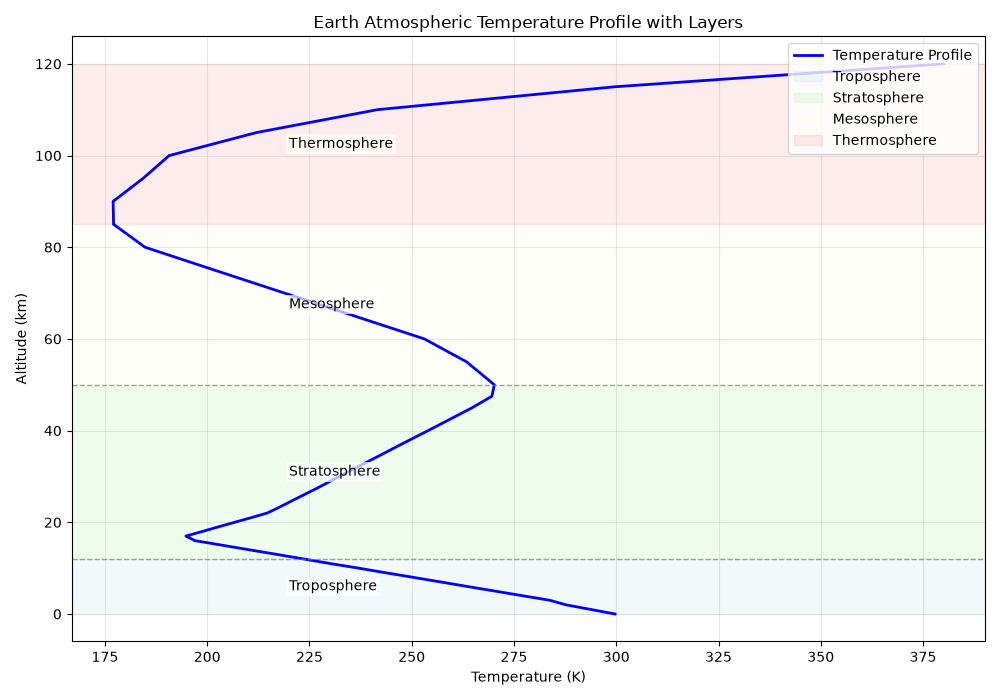

In [57]:
plt.figure(figsize=(10, 7))

# Main temperature profile
plt.plot(df_atmospheric_profile_table["TEMP_K"], 
         df_atmospheric_profile_table["ALT_km"], 
         color='blue', linewidth=2, label='Temperature Profile')

# Standard atmospheric layer boundaries (approximate)
layers = [
    (0, 12, "Troposphere", "lightblue"),
    (12, 50, "Stratosphere", "lightgreen"),
    (50, 85, "Mesosphere", "lightyellow"),
    (85, 120, "Thermosphere", "lightcoral")
]

for bottom, top, name, color in layers:
    plt.axhspan(bottom, top, alpha=0.15, color=color, label=name)
    # Label in the middle of the layer
    mid = (bottom + top) / 2
    plt.text(220, mid, name, fontsize=10, va='center', ha='left', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

plt.xlabel("Temperature (K)")
plt.ylabel("Altitude (km)")
plt.title("Earth Atmospheric Temperature Profile with Layers")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

# Optional: mark tropopause etc.
plt.axhline(12, color='gray', linestyle='--', alpha=0.7, linewidth=1)
plt.axhline(50, color='gray', linestyle='--', alpha=0.7, linewidth=1)

plt.tight_layout()
plt.show()

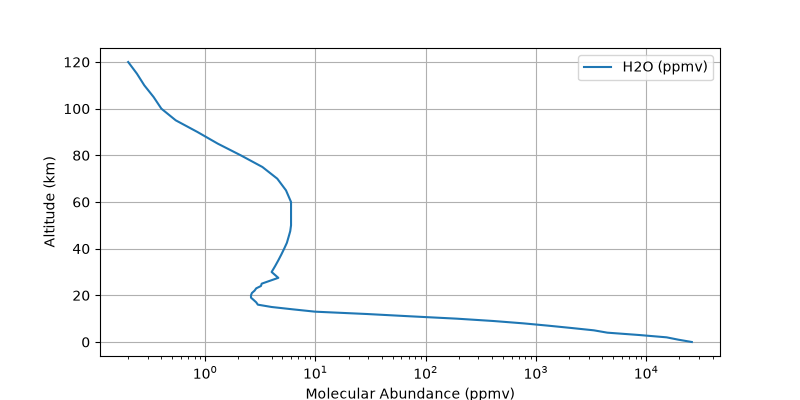

In [58]:
# Plotting molecular abundance profiles 

plt.figure(figsize=(8, 4))
plt.plot(df_atmospheric_profile_table["H2O_ppmv"], df_atmospheric_profile_table["ALT_km"], label="H2O (ppmv)")
# plt.plot( df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["CH4_ppmv"], label="CH4 (ppmv)")
# plt.plot(df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["O3_ppmv"], label="O3 (ppmv)")
# plt.plot(df_atmospheric_profile_table["ALT_km"], df_atmospheric_profile_table["N2O_ppmv"], label="N2O (ppmv)")
plt.xscale("log")
plt.xlabel("Molecular Abundance (ppmv)")
plt.ylabel("Altitude (km)")
plt.grid(True)
plt.legend()
plt.show()

# Test Reflectivity Spectra - ✅

In [61]:
# Example
mols = [('H2O', 1), ('N2O', 1)]  # adjust isotopes
alts =  range(len(df_atmospheric_profile_table))  # or subset

wl, trans = compute_reflectivity(mols, dwn=0.01, cloud_top= 10)

Computing reflectivity above cloud top at 10 km (40 layers)
Looking for column: H2O_ppmv
→ Processing H2O iso1
Computing coef for H2O iso1 at alt 0
{'self': np.float64(0.0259), 'air': np.float64(0.9741)}
0.277646 seconds elapsed for abscoef; nlines = 528
Computing coef for H2O iso1 at alt 1
{'self': np.float64(0.0195), 'air': np.float64(0.9805)}
0.245256 seconds elapsed for abscoef; nlines = 528
Computing coef for H2O iso1 at alt 2
{'self': np.float64(0.0153), 'air': np.float64(0.9847)}
0.245739 seconds elapsed for abscoef; nlines = 528
Computing coef for H2O iso1 at alt 3
{'self': np.float64(0.0086), 'air': np.float64(0.9914)}
0.243510 seconds elapsed for abscoef; nlines = 528
Computing coef for H2O iso1 at alt 4
{'self': np.float64(0.00444), 'air': np.float64(0.99556)}
0.246930 seconds elapsed for abscoef; nlines = 528
Computing coef for H2O iso1 at alt 5
{'self': np.float64(0.00335), 'air': np.float64(0.99665)}
0.339392 seconds elapsed for abscoef; nlines = 528
Computing coef for H2

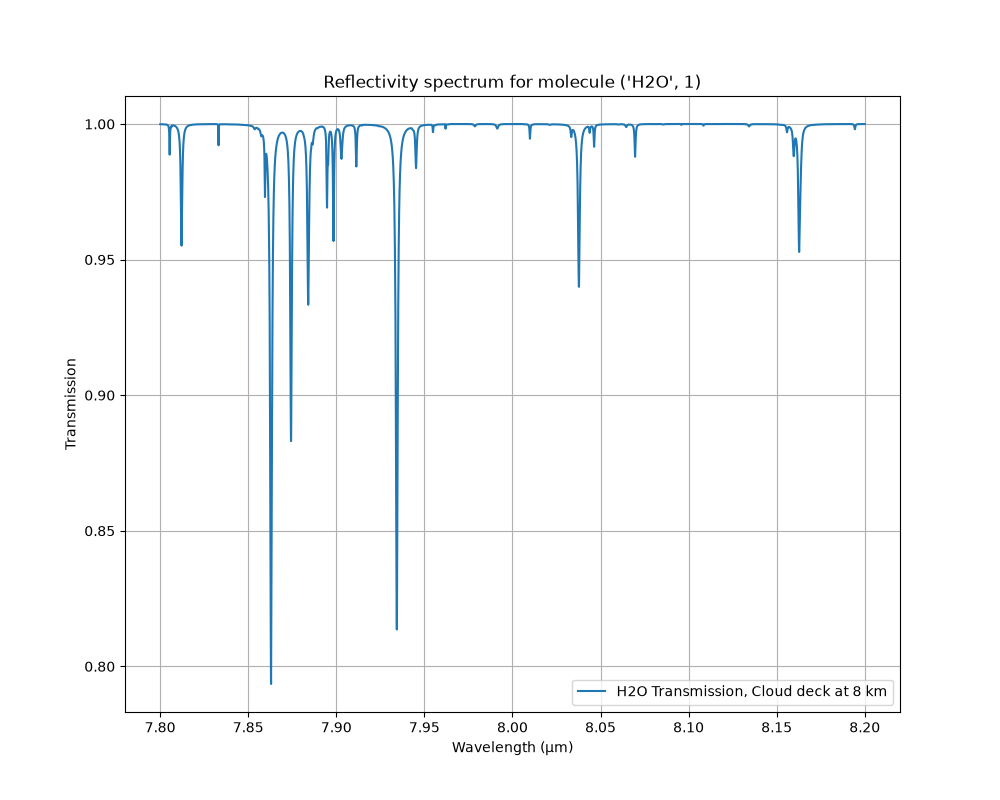

In [ ]:
plt.figure(figsize=(10, 8))
plt.title(f"Reflectivity spectrum for molecule {mols[0]}")
plt.plot(wl, trans, label=f"{mols[0][0]} Transmission, Cloud deck at {8} km")
plt.xlabel("Wavelength (μm)")
plt.ylabel("Transmission")
# plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
snr = 10
noisy_trans, errors = inject_poisson_noise(trans, snr, mode='gaussian_approx')

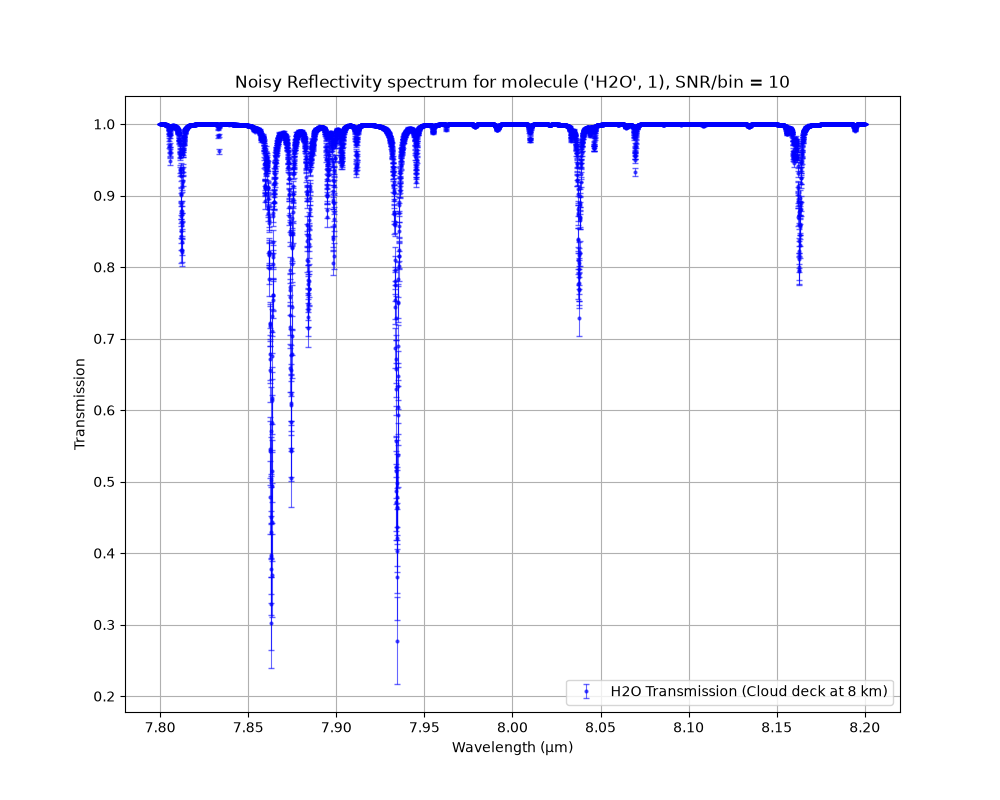

In [ ]:
plt.figure(figsize=(10, 8))
plt.title(f"Noisy Reflectivity spectrum for molecule {mols[0]}, SNR/bin = {snr}")
plt.errorbar(wl, noisy_trans, yerr=errors, fmt='o', markersize=2, 
             color='blue', ecolor='blue', elinewidth=0.8, capsize=2, 
             alpha=0.6, label=f"{mols[0][0]} Transmission (Cloud deck at 8 km)")
plt.xlabel("Wavelength (μm)")
plt.ylabel("Transmission")
# plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

# Dictionary generation test ✅

In [35]:
scenarios = [[('CH4', 1), ('N2O', 1)], [('H2O', 1)]]
resolutions = [500, 1000, 5000, 10000, 100000]
snrs = [5, 10, 25, 50, 100]

res_dict = generate_res_dict(scenarios, resolutions, snrs, cloud_top=8.0, albedo=0.3)

Computing high-res for scenario: CH4+N2O
Computing reflectivity above cloud top at 8.0 km (42 layers)
Looking for column: CH4_ppmv
→ Processing CH4 iso1
Computing coef for CH4 iso1 at alt 0
{'self': np.float64(1.7e-06), 'air': np.float64(0.9999983)}
2.799328 seconds elapsed for abscoef; nlines = 4093
Computing coef for CH4 iso1 at alt 1
{'self': np.float64(1.7e-06), 'air': np.float64(0.9999983)}
2.224905 seconds elapsed for abscoef; nlines = 4093
Computing coef for CH4 iso1 at alt 2
{'self': np.float64(1.7e-06), 'air': np.float64(0.9999983)}
2.180049 seconds elapsed for abscoef; nlines = 4093
Computing coef for CH4 iso1 at alt 3
{'self': np.float64(1.7e-06), 'air': np.float64(0.9999983)}
2.359466 seconds elapsed for abscoef; nlines = 4093
Computing coef for CH4 iso1 at alt 4
{'self': np.float64(1.7e-06), 'air': np.float64(0.9999983)}
2.406039 seconds elapsed for abscoef; nlines = 4093
Computing coef for CH4 iso1 at alt 5
{'self': np.float64(1.7e-06), 'air': np.float64(0.9999983)}
2.298

In [40]:
res_dict[500]['CH4+N2O'].keys()

dict_keys(['wavelength_grid', 'reflectivity_clean', 'resolution', 'reflectivity_snr5', 'error_snr5', 'reflectivity_snr10', 'error_snr10', 'reflectivity_snr25', 'error_snr25', 'reflectivity_snr50', 'error_snr50', 'reflectivity_snr100', 'error_snr100'])

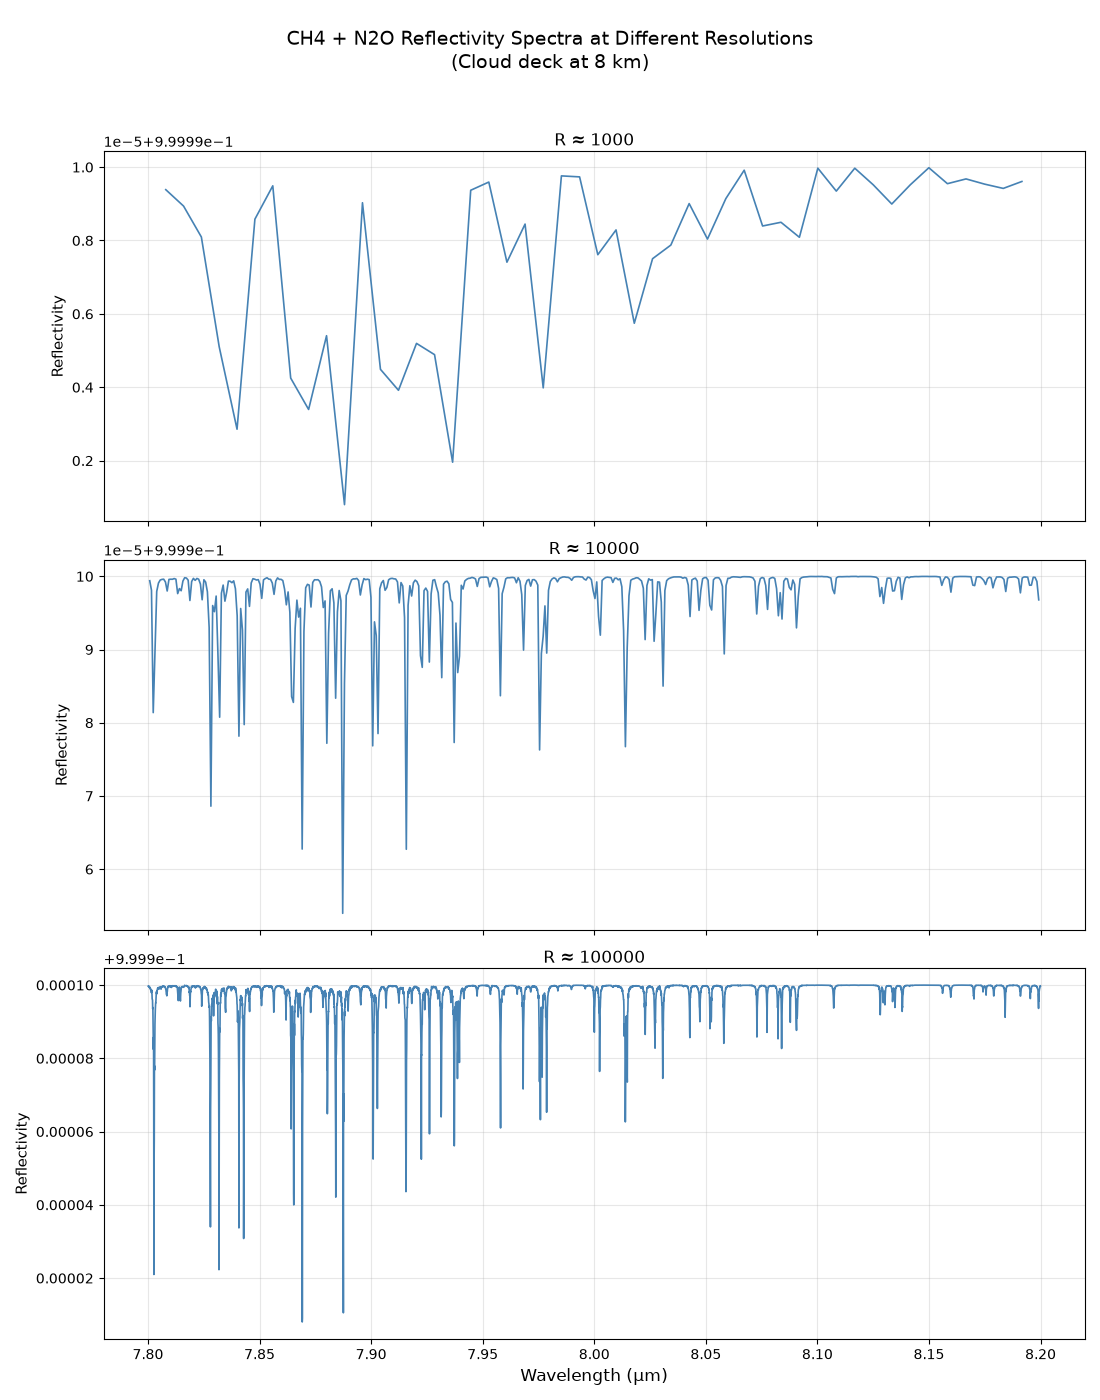

In [45]:
# Vertical grid plot
resolutions_to_plot = [1000, 10000, 100000]
snr_to_plot = 5

fig, axes = plt.subplots(len(resolutions_to_plot), 1, figsize=(11, 14), sharex=True)

mol_name = 'CH4+N2O'   # since you only have H2O right now

for i, R in enumerate(sorted(resolutions_to_plot)):
    ax = axes[i]
    
    if R in res_dict and mol_name in res_dict[R]:
        data = res_dict[R][mol_name]
        wl = data['wavelength_grid']
        refl = data[f'reflectivity_snr{snr_to_plot}']
        
        ax.plot(wl, refl, color='steelblue', linewidth=1.2)
        ax.set_ylabel("Reflectivity", fontsize=11)
        ax.set_title(f"R ≈ {R}", fontsize=12, pad=4)
        # ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        
        # Optional: annotate max/min
        # ax.text(0.02, 0.92, f"min={np.nanmin(refl):.3f}", transform=ax.transAxes, 
        #         fontsize=9, color='darkred')
    else:
        ax.text(0.5, 0.5, f"No data for R={R}", ha='center', va='center', transform=ax.transAxes)
        ax.set_ylim(0, 1)

# Only put x-label on the bottom plot
axes[-1].set_xlabel("Wavelength (μm)", fontsize=12)

fig.suptitle("CH4 + N2O Reflectivity Spectra at Different Resolutions\n(Cloud deck at 8 km)", 
             fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()